**LOGISTIC REGRESSION**


---

Initial implementation by - **Rina Peshori**

Extended with additional evaluation metrices (ROC Curve, F1-Score, etc.) # New Section


In [24]:
#############################
#      NOTEBOOK SETTINGS    #
#############################

USE_AUGMENTATION = False
N_SYNTH_SAMPLES = None
RUN_KFOLD = True
KFOLD_SPLITS = 5


In [25]:
#############################
#       MOUNT GOOGLE DRIVE  #
#############################

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
#############################
#      PROJECT SETTINGS     #
#############################

import os

PROJECT_ROOT = "/content/drive/MyDrive/ML Group Project CSCI 635"
DATA_FILE = os.path.join(PROJECT_ROOT, "data", "wfh_burnout_dataset.csv")

print("Project root:", PROJECT_ROOT)
print("Data file:", DATA_FILE)
print("Dataset exists:", os.path.exists(DATA_FILE))


Project root: /content/drive/MyDrive/ML Group Project CSCI 635
Data file: /content/drive/MyDrive/ML Group Project CSCI 635/data/wfh_burnout_dataset.csv
Dataset exists: True


In [27]:
#############################
#       IMPORT LIBRARIES    #
#############################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neighbors import KernelDensity
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


In [28]:
#############################
#      GLOBAL SETTINGS      #
#############################

NUM_TARGET_CLASSES = 3
ITERATIONS = 5000
ETA = 0.01
THRESHOLD = 1e-4
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)


In [29]:
#############################
#       LOAD DATASET        #
#############################

data = pd.read_csv(DATA_FILE)
print("Dataset shape:", data.shape)
data.head()


Dataset shape: (2000, 14)


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [30]:
#############################
#      PREPROCESS DATA      #
#############################

def preprocess_dataset(dataframe):
    df = dataframe.copy()
    df = pd.get_dummies(df, columns=["day_type"], drop_first=True)
    df["burnout_risk"] = df["burnout_risk"].map({"High": 2, "Medium": 1, "Low": 0})

    X = df.drop(["burnout_risk", "burnout_score", "user_id"], axis=1)
    y = df["burnout_risk"]

    return X, y

X, y = preprocess_dataset(data)

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())
print(y.value_counts().sort_index())


X shape: (2000, 11)
y shape: (2000,)


,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,day_type_Weekend
0,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,False
1,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,False
2,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,True
3,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,False
4,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,True


burnout_risk
0    1019
1     843
2     138
Name: count, dtype: int64


In [31]:
#############################
#     TRAIN/TEST SPLIT      #
#############################

def train_test(split=0.2):
    X, y = preprocess_dataset(pd.read_csv(DATA_FILE))

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=split,
        stratify=y,
        random_state=42
    )
    return X_train, X_test, y_train, y_test

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test()

print(X_train_raw.shape, X_test_raw.shape, y_train_raw.shape, y_test_raw.shape)


(1600, 11) (400, 11) (1600,) (400,)


In [32]:
#############################
#    AUGMENTATION HELPERS   #
#############################

def generate_synthetic_data(X, y, n_samples=2000, rand_state=11):
    y = np.asarray(y).reshape(-1)
    classes, counts = np.unique(y, return_counts=True)

    kdes = {}
    bandwidth_params = {"bandwidth": np.arange(0.01, 1, 0.05)}

    for cls in classes:
        X_cls = X[y == cls]
        grid_search = GridSearchCV(KernelDensity(), bandwidth_params, cv=5)
        grid_search.fit(X_cls.values)
        kdes[cls] = grid_search.best_estimator_

    freqs = counts / counts.sum()
    samples_per_class = np.floor(freqs * n_samples).astype(int)

    remainder = n_samples - samples_per_class.sum()
    if remainder > 0:
        idxs = np.argsort(-counts)
        for i in range(remainder):
            samples_per_class[idxs[i % len(classes)]] += 1

    new_X = []
    new_y = []

    for cls, n in zip(classes, samples_per_class):
        new_data = kdes[cls].sample(n, random_state=rand_state)
        new_X.append(new_data)
        new_y.append(np.full(n, cls))

    X_synth = np.vstack(new_X)
    y_synth = np.concatenate(new_y)

    df_X_synth = pd.DataFrame(X_synth, columns=X.columns)
    df_y_synth = pd.Series(y_synth)

    return df_X_synth, df_y_synth


def augment_training_data(X, y, n_samples=2000):
    df_X_synth, df_y_synth = generate_synthetic_data(X, y, n_samples=n_samples)
    X_aug = pd.concat([X, df_X_synth], ignore_index=True)
    y_aug = pd.concat([pd.Series(y).reset_index(drop=True), df_y_synth], ignore_index=True)
    return X_aug, y_aug


In [33]:
#############################
#      DATA PREPARATION     #
#############################

y_train = pd.Series(y_train_raw).reset_index(drop=True)
y_test = pd.Series(y_test_raw).reset_index(drop=True)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_train_raw.columns
)

if USE_AUGMENTATION:
    synth_n = len(X_train_scaled) if N_SYNTH_SAMPLES is None else N_SYNTH_SAMPLES
    X_train, y_train = augment_training_data(
        X_train_scaled,
        y_train,
        n_samples=synth_n
    )
    print("Using augmented training data")
else:
    X_train, y_train = X_train_scaled, y_train
    print("Using non-augmented training data")

X_test = X_test_scaled

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


Using non-augmented training data
X_train shape: (1600, 11)
X_test shape: (400, 11)
y_train shape: (1600,)
y_test shape: (400,)


In [34]:
#############################
# SIGMOID AND LOSS FUNCTION #
#############################

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def compute_loss(y, p):
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))


In [35]:
#############################
#     PREPARE MATRICES      #
#############################

X_train_matrix = np.hstack((np.ones((len(X_train), 1)), X_train.values))
X_test_matrix  = np.hstack((np.ones((len(X_test), 1)), X_test.values))

y_train_matrix = y_train.values.reshape(-1)
y_test_matrix = y_test.values.reshape(-1)

print("Train matrix shape:", X_train_matrix.shape)
print("Test matrix shape:", X_test_matrix.shape)


Train matrix shape: (1600, 12)
Test matrix shape: (400, 12)


In [36]:
#############################
#  1 v/s REST LOGISTIC REG. #
#############################

beta_arr = []
loss_history = {}

for k in range(NUM_TARGET_CLASSES):
    print(f"Training class {k} v/s rest")

    y_binary = (y_train_matrix == k).astype(int)
    beta = np.zeros(X_train_matrix.shape[1])
    prev_loss = float("inf")
    class_losses = []

    for i in range(1, ITERATIONS + 1):
        p = sigmoid(np.dot(X_train_matrix, beta))
        p = np.clip(p, 1e-9, 1 - 1e-9)

        loss = compute_loss(y_binary, p)
        class_losses.append(loss)

        if abs(prev_loss - loss) < THRESHOLD:
            print(f"Converged at iteration {i}")
            break

        prev_loss = loss

        num_pos = np.sum(y_binary == 1)
        num_neg = np.sum(y_binary == 0)

        pos_weight = len(y_binary) / (2 * num_pos)
        neg_weight = len(y_binary) / (2 * num_neg)

        weights = np.where(y_binary == 1, pos_weight, neg_weight)

        gradient = np.dot(X_train_matrix.T, weights * (p - y_binary))

        beta = beta - ETA * gradient

        if i % 500 == 0:
            print(f"Iteration {i}, loss: {loss}")

    beta_arr.append(beta)
    loss_history[k] = class_losses

beta_arr = np.array(beta_arr)
print("beta_arr shape:", beta_arr.shape)


Training class 0 v/s rest
Converged at iteration 21
Training class 1 v/s rest
Iteration 500, loss: 0.8835796102012202
Iteration 1000, loss: 2.0553322351342955
Iteration 1500, loss: 1.043087617238398
Iteration 2000, loss: 1.0936374610176873
Iteration 2500, loss: 1.2195436154510637
Iteration 3000, loss: 1.6898306239458267
Converged at iteration 3435
Training class 2 v/s rest
Iteration 500, loss: 0.022177742243713362
Iteration 1000, loss: 0.019159499926670046
Iteration 1500, loss: 0.01599867642371289
Iteration 2000, loss: 0.015317083448170083
Iteration 2500, loss: 0.01495134562464338
Iteration 3000, loss: 0.014798583097426687
Iteration 3500, loss: 0.014825577695783273
Iteration 4000, loss: 0.01503763662277566
Iteration 4500, loss: 0.015498347994823872
Iteration 5000, loss: 0.01647386842341125
beta_arr shape: (3, 12)


In [37]:
#############################
#    TRAINING EVALUATION    #
#############################

train_probabilities = []

for beta in beta_arr:
    z = np.dot(X_train_matrix, beta)
    train_probabilities.append(z)

train_probabilities = np.array(train_probabilities)
y_train_pred = np.argmax(train_probabilities, axis=0)

train_accuracy = np.mean(y_train_matrix == y_train_pred)
print(f"Training Accuracy: {train_accuracy:.4f}")


Training Accuracy: 0.9375


In [38]:
#############################
#        PREDICTION         #
#############################

probabilities = []

for beta in beta_arr:
    z = np.dot(X_test_matrix, beta)
    probabilities.append(z)

probabilities = np.array(probabilities)
y_pred = np.argmax(probabilities, axis=0)

print("Probabilities shape:", probabilities.T.shape)
print("Prediction shape:", y_pred.shape)
print(y_pred[:10])


Probabilities shape: (400, 3)
Prediction shape: (400,)
[1 1 1 0 1 0 0 1 1 1]


In [39]:
#############################
#          ACCURACY         #
#############################

accuracy = np.mean(y_test_matrix == y_pred)
print(f"Accuracy: {accuracy:.4f}")


Accuracy: 0.9475


In [40]:
#############################
#     PER CLASS ACCURACY    #
#############################

for i in range(NUM_TARGET_CLASSES):
    k = (y_test_matrix == i)
    acc = np.mean(y_pred[k] == i)
    print(f"Class {i} accuracy: {acc:.4f}")


Class 0 accuracy: 0.9706
Class 1 accuracy: 0.9822
Class 2 accuracy: 0.5556


In [41]:
#############################
#     CONFUSION MATRIX      #
#############################

cm = pd.crosstab(y_test_matrix, y_pred, rownames=['Actual'], colnames=['Predicted'])
display(cm)


Predicted,0,1,2
Actual,,,
0,198,6,0
1,3,166,0
2,0,12,15


In [42]:
#############################
#  PRECISION / RECALL / F1  #
#############################

print(confusion_matrix(y_test_matrix, y_pred))
print(classification_report(y_test_matrix, y_pred, zero_division=0))


[[198   6   0]
 [  3 166   0]
 [  0  12  15]]
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       204
           1       0.90      0.98      0.94       169
           2       1.00      0.56      0.71        27

    accuracy                           0.95       400
   macro avg       0.96      0.84      0.88       400
weighted avg       0.95      0.95      0.94       400



In [43]:
#############################
#   PREDICTED DISTRIBUTION  #
#############################

print("Predicted class counts:")
print(np.bincount(y_pred))

print("Actual class counts:")
print(np.bincount(y_test_matrix))


Predicted class counts:
[201 184  15]
Actual class counts:
[204 169  27]


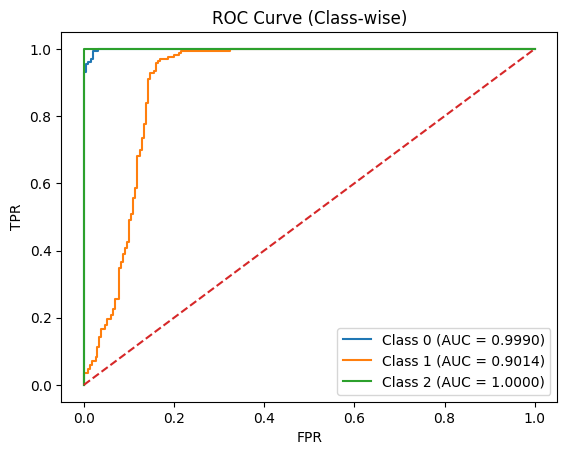

In [44]:
#############################
#  ROC CURVE (CLASS-WISE)   #
#############################

y_test_one_hot = label_binarize(y_test_matrix, classes=[0, 1, 2])
probs = probabilities.T

for i in range(NUM_TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.4f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Class-wise)")
plt.legend()
plt.show()


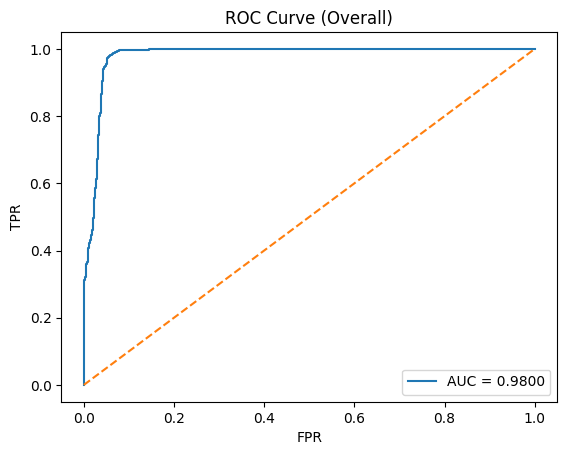

In [45]:
#############################
#    ROC CURVE (OVERALL)    #
#############################

probs = probabilities.T
fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), probs.ravel())
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (Overall)")
plt.legend()
plt.show()


In [46]:
#############################
#       K-FOLD SECTION      #
#############################

if RUN_KFOLD:
    X_full, y_full = preprocess_dataset(pd.read_csv(DATA_FILE))
    y_full = pd.Series(y_full).reset_index(drop=True)

    skf = StratifiedKFold(n_splits=KFOLD_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    fold_results = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full), start=1):
        print(f"\nFold {fold_idx}/{KFOLD_SPLITS}")

        X_fold_train = X_full.iloc[train_idx].reset_index(drop=True)
        y_fold_train = y_full.iloc[train_idx].reset_index(drop=True)
        X_val = X_full.iloc[val_idx].reset_index(drop=True)
        y_val = y_full.iloc[val_idx].reset_index(drop=True)

        scaler = StandardScaler()
        X_fold_train_scaled = pd.DataFrame(
            scaler.fit_transform(X_fold_train),
            columns=X_full.columns
        )
        X_val_scaled = pd.DataFrame(
            scaler.transform(X_val),
            columns=X_full.columns
        )

        if USE_AUGMENTATION:
            synth_n = len(X_fold_train_scaled) if N_SYNTH_SAMPLES is None else N_SYNTH_SAMPLES
            X_fold_train_scaled, y_fold_train = augment_training_data(
                X_fold_train_scaled,
                y_fold_train,
                n_samples=synth_n
            )

        X_fold_train_matrix = np.hstack((np.ones((len(X_fold_train_scaled), 1)), X_fold_train_scaled.values))
        X_val_matrix = np.hstack((np.ones((len(X_val_scaled), 1)), X_val_scaled.values))

        y_fold_train_matrix = y_fold_train.values.reshape(-1)
        y_val_matrix = y_val.values.reshape(-1)

        beta_arr_fold = []

        for k in range(NUM_TARGET_CLASSES):
            y_binary = (y_fold_train_matrix == k).astype(int)
            beta = np.zeros(X_fold_train_matrix.shape[1])
            prev_loss = float("inf")

            for i in range(1, ITERATIONS + 1):
                p = sigmoid(np.dot(X_fold_train_matrix, beta))
                p = np.clip(p, 1e-9, 1 - 1e-9)

                loss = compute_loss(y_binary, p)

                if abs(prev_loss - loss) < THRESHOLD:
                    break

                prev_loss = loss

                num_pos = np.sum(y_binary == 1)
                num_neg = np.sum(y_binary == 0)

                pos_weight = len(y_binary) / (2 * num_pos)
                neg_weight = len(y_binary) / (2 * num_neg)

                weights = np.where(y_binary == 1, pos_weight, neg_weight)

                gradient = np.dot(X_fold_train_matrix.T, weights * (p - y_binary))
                beta = beta - ETA * gradient

            beta_arr_fold.append(beta)

        beta_arr_fold = np.array(beta_arr_fold)

        train_scores = []
        for beta in beta_arr_fold:
            train_scores.append(np.dot(X_fold_train_matrix, beta))
        train_scores = np.array(train_scores)
        y_train_pred = np.argmax(train_scores, axis=0)

        val_scores = []
        for beta in beta_arr_fold:
            val_scores.append(np.dot(X_val_matrix, beta))
        val_scores = np.array(val_scores)
        y_val_pred = np.argmax(val_scores, axis=0)

        train_acc = np.mean(y_train_pred == y_fold_train_matrix)
        val_acc = np.mean(y_val_pred == y_val_matrix)

        from sklearn.metrics import f1_score
        val_macro_f1 = f1_score(y_val_matrix, y_val_pred, average="macro", zero_division=0)

        print(f"Training Accuracy: {train_acc:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        print(f"Validation Macro F1: {val_macro_f1:.4f}")

        fold_results.append({
            "fold": fold_idx,
            "train_accuracy": train_acc,
            "val_accuracy": val_acc,
            "val_macro_f1": val_macro_f1
        })

    fold_df = pd.DataFrame(fold_results)
    display(fold_df)

    print(f"Average Train Accuracy: {fold_df['train_accuracy'].mean():.4f}")
    print(f"Average Validation Accuracy: {fold_df['val_accuracy'].mean():.4f}")
    print(f"Average Validation Macro F1: {fold_df['val_macro_f1'].mean():.4f}")
else:
    print("RUN_KFOLD is False, so this section is skipped.")



Fold 1/5
Training Accuracy: 0.8800
Validation Accuracy: 0.8900
Validation Macro F1: 0.6117

Fold 2/5
Training Accuracy: 0.9219
Validation Accuracy: 0.9175
Validation Macro F1: 0.7907

Fold 3/5
Training Accuracy: 0.8794
Validation Accuracy: 0.8675
Validation Macro F1: 0.5953

Fold 4/5
Training Accuracy: 0.8712
Validation Accuracy: 0.8875
Validation Macro F1: 0.6110

Fold 5/5
Training Accuracy: 0.8962
Validation Accuracy: 0.8950
Validation Macro F1: 0.6166


,fold,train_accuracy,val_accuracy,val_macro_f1
0,1,0.880000,0.8900,0.611711
1,2,0.921875,0.9175,0.790665
2,3,0.879375,0.8675,0.595307
3,4,0.871250,0.8875,0.610995
4,5,0.896250,0.8950,0.616611


Average Train Accuracy: 0.8897
Average Validation Accuracy: 0.8915
Average Validation Macro F1: 0.6451
